# Benchmark: Representaciones Semánticas para Navegación Robótica

Este notebook evalúa tres estrategias de representación semántica para un sistema de
navegación semántica basado en recuperación visual (**retrieval**) con **ChromaDB**:

| # | Método | Descripción |
|---|--------|-------------|
| 1 | **SigLIP Baseline** | Embeddings visuales directos — `google/siglip-base-patch16-224` |
| 2 | **SigLIP + YOLO** | Embeddings visuales + detección `YOLOv8n` (búsqueda híbrida) |
| 3 | **Qwen2-VL** | Descripción de escena con `Qwen/Qwen2-VL-2B-Instruct` + embedding textual |

**Métricas medidas estrictamente:**
- `T. Construcción (s)` — procesamiento de imágenes + escritura en ChromaDB
- `T. Retrieval (ms)` — latencia de consulta: media, mínimo y máximo
- `Top-1 Acc`, `Top-3 Acc` — match exacto de nodo en top-1 / top-3
- `Room Acc` — match de habitación en top-3 (métrica principal para navegación)


In [2]:
import os
import sys

# FIX for nvrtc-builtins.so.13.0 in PyTorch + CUDA 13
_site_packages = next((p for p in sys.path if "site-packages" in p), None)
if _site_packages:
    _cu13_lib = os.path.join(_site_packages, "nvidia", "cu13", "lib")
    if os.path.exists(_cu13_lib):
        os.environ["LD_LIBRARY_PATH"] = _cu13_lib + ":" + os.environ.get("LD_LIBRARY_PATH", "")



In [3]:
# ============================================================
# Verificación e instalación de dependencias
# ============================================================
import subprocess, sys, os, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw
import torch
import chromadb
import transformers

print(f"Python      : {sys.version.split()[0]}")
print(f"PyTorch     : {torch.__version__}")
print(f"Transformers: {transformers.__version__}")
print(f"ChromaDB    : {chromadb.__version__}")
print(f"Dispositivo : {'CUDA — ' + torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")
if transformers.__version__ < "4.45.0":
    print("\nAVISO: Qwen2-VL requiere transformers>=4.45.0")
    print("       pip install \"transformers>=4.45.0\"")

Python      : 3.12.3
PyTorch     : 2.11.0+cu130
Transformers: 5.3.0
ChromaDB    : 1.5.8
Dispositivo : CUDA — NVIDIA GeForce RTX 2060


---
## Sección 1: Setup y Dataset

Se construye un grafo topológico con **24 nodos** en **6 habitaciones**
(`bathroom`, `bedroom`, `children_room`, `garage`, `kitchen`, `livingroom`),
usando imágenes reales del directorio `./siglip/images/`.

Por cada habitación se seleccionan **4 imágenes como nodos del mapa** (índices 0–3)
y **1 imagen de consulta** (índice 4, no presente en el mapa) que representa
lo que el robot capturaría en tiempo de ejecución.


In [4]:
# ============================================================
# 1.1  Configuración de directorios y parámetros globales
# ============================================================
WORK_DIR          = os.path.abspath("./benchmark_data")
IMAGE_SOURCES_DIR = os.path.abspath("./siglip/images")   # imágenes reales
CHROMA_DIR        = os.path.join(WORK_DIR, "chroma_db")

os.makedirs(CHROMA_DIR, exist_ok=True)

DEVICE         = "cuda" if torch.cuda.is_available() else "cpu"
NODES_PER_ROOM = 4    # imágenes de mapa por habitación (índices 0..3)
QUERY_IDX      = 4    # imagen de consulta por habitación (índice 4, excluida del mapa)

# ============================================================
# 1.2  Habitaciones disponibles y rutas de imagen
# ============================================================
ROOMS = sorted([
    d for d in os.listdir(IMAGE_SOURCES_DIR)
    if os.path.isdir(os.path.join(IMAGE_SOURCES_DIR, d))
])
print(f"Habitaciones encontradas ({len(ROOMS)}): {ROOMS}")


def get_room_images(room_id: str) -> list:
    """Devuelve lista ordenada de rutas de imagen para una habitación."""
    room_dir = os.path.join(IMAGE_SOURCES_DIR, room_id)
    files = sorted([
        os.path.join(room_dir, f)
        for f in os.listdir(room_dir)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ])
    return files


# ============================================================
# 1.3  DataFrame del mapa semántico
# ============================================================
rows    = []
rng_pos = np.random.default_rng(42)

for _r_idx, _room_id in enumerate(ROOMS):
    _imgs = get_room_images(_room_id)
    for _n in range(NODES_PER_ROOM):
        _node_id = f"node_{_r_idx * NODES_PER_ROOM + _n:03d}"
        _x       = _r_idx * 3.0 + float(rng_pos.uniform(-0.4, 0.4))
        _y       = _n * 1.5     + float(rng_pos.uniform(-0.25, 0.25))
        rows.append({"node_id": _node_id, "x": round(_x, 2), "y": round(_y, 2),
                     "room_id": _room_id, "image_path": _imgs[_n]})

df_map = pd.DataFrame(rows)
print(f"\nMapa semántico: {len(df_map)} nodos — {df_map['room_id'].nunique()} habitaciones\n")
print(df_map.groupby("room_id").size().rename("nodos").to_frame().to_string())
df_map.head(8)


Habitaciones encontradas (6): ['bathroom', 'bedroom', 'children_room', 'garage', 'kitchen', 'livingroom']

Mapa semántico: 24 nodos — 6 habitaciones

               nodos
room_id             
bathroom           4
bedroom            4
children_room      4
garage             4
kitchen            4
livingroom         4


,node_id,x,y,room_id,image_path
0,node_000,0.22,-0.03,bathroom,/home/junior/visual_semantic_navigation/experi...
1,node_001,0.29,1.60,bathroom,/home/junior/visual_semantic_navigation/experi...
2,node_002,-0.32,3.24,bathroom,/home/junior/visual_semantic_navigation/experi...
3,node_003,0.21,4.64,bathroom,/home/junior/visual_semantic_navigation/experi...
4,node_004,2.70,-0.02,bedroom,/home/junior/visual_semantic_navigation/experi...
5,node_005,2.90,1.71,bedroom,/home/junior/visual_semantic_navigation/experi...
6,node_006,3.12,3.16,bedroom,/home/junior/visual_semantic_navigation/experi...
7,node_007,2.95,4.36,bedroom,/home/junior/visual_semantic_navigation/experi...


In [5]:
# ============================================================
# 1.4  Consultas de prueba con ground truth
# ============================================================
# Por cada habitación se usa la imagen en el índice QUERY_IDX (no incluida
# en el mapa) como consulta. Ground truth a nivel de habitación.
test_queries = []
for _room_id in ROOMS:
    _gt_node  = df_map[df_map["room_id"] == _room_id]["node_id"].iloc[0]
    _imgs     = get_room_images(_room_id)
    _img_path = _imgs[QUERY_IDX]
    test_queries.append({
        "query_id":   f"query_{_room_id}",
        "gt_node_id": _gt_node,
        "gt_room_id": _room_id,
        "image_path": _img_path,
    })

df_queries = pd.DataFrame(test_queries)
n_q = len(df_queries)   # usado en todas las secciones de evaluación
print(f"Consultas de prueba: {n_q}\n")
display(df_queries)

# ============================================================
# 1.5  Cliente ChromaDB 
# ============================================================
chroma_client = chromadb.PersistentClient(path=CHROMA_DIR)
print(f"\nChromaDB inicializado en: {CHROMA_DIR}")


Consultas de prueba: 6



,query_id,gt_node_id,gt_room_id,image_path
0,query_bathroom,node_000,bathroom,/home/junior/visual_semantic_navigation/experi...
1,query_bedroom,node_004,bedroom,/home/junior/visual_semantic_navigation/experi...
2,query_children_room,node_008,children_room,/home/junior/visual_semantic_navigation/experi...
3,query_garage,node_012,garage,/home/junior/visual_semantic_navigation/experi...
4,query_kitchen,node_016,kitchen,/home/junior/visual_semantic_navigation/experi...
5,query_livingroom,node_020,livingroom,/home/junior/visual_semantic_navigation/experi...



ChromaDB inicializado en: /home/junior/visual_semantic_navigation/experiments/benchmark_data/chroma_db


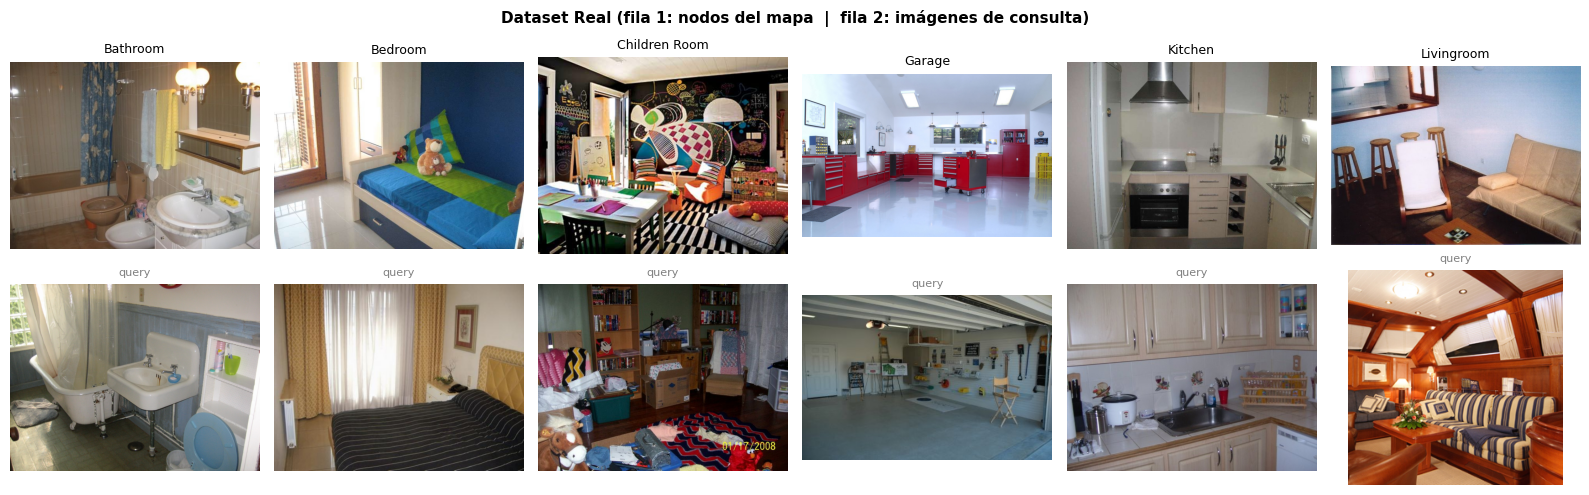

In [6]:
# ============================================================
# 1.6  Visualización del dataset real
# ============================================================
fig, axes = plt.subplots(2, len(ROOMS), figsize=(16, 5))
fig.suptitle(
    "Dataset Real (fila 1: nodos del mapa  |  fila 2: imágenes de consulta)",
    fontsize=11, fontweight="bold",
)
for _col, _room_id in enumerate(ROOMS):
    _node_path = df_map[df_map["room_id"] == _room_id]["image_path"].iloc[0]
    axes[0, _col].imshow(Image.open(_node_path))
    axes[0, _col].set_title(_room_id.replace("_", " ").title(), fontsize=9)
    axes[0, _col].axis("off")
    _q_path = df_queries[df_queries["gt_room_id"] == _room_id]["image_path"].iloc[0]
    axes[1, _col].imshow(Image.open(_q_path))
    axes[1, _col].set_title("query", fontsize=8, color="gray")
    axes[1, _col].axis("off")
plt.tight_layout()
plt.show()


---
## Sección 2: Experimento 1 — Representación Visual Pura (SigLIP Baseline)

Los nodos se indexan usando **únicamente el embedding de imagen** generado por SigLIP.
El retrieval es una búsqueda ANN directa sobre los vectores almacenados en ChromaDB,
sin ningún post-procesamiento adicional. Sirve como **línea base** para comparar
el impacto de las representaciones más ricas.


In [7]:
# ============================================================
# 2.1  Carga del modelo SigLIP
# ============================================================
from transformers import AutoProcessor, AutoModel

SIGLIP_MODEL_ID = "google/siglip-base-patch16-224"
print(f"Cargando SigLIP: {SIGLIP_MODEL_ID} ...")
_t0 = time.perf_counter()
siglip_processor = AutoProcessor.from_pretrained(SIGLIP_MODEL_ID, use_fast=False)
siglip_model     = AutoModel.from_pretrained(SIGLIP_MODEL_ID)
siglip_model.eval().to(DEVICE)
print(f"  Listo en {time.perf_counter() - _t0:.1f}s  |  "
      f"Dim. visual: {siglip_model.config.vision_config.hidden_size}  |  "
      f"Dispositivo: {DEVICE}")


Cargando SigLIP: google/siglip-base-patch16-224 ...


Loading weights: 100%|██████████| 408/408 [00:00<00:00, 2033.91it/s]


  Listo en 4.4s  |  Dim. visual: 768  |  Dispositivo: cuda


In [8]:
# ============================================================
# 2.2  Funciones auxiliares de embedding
# ============================================================

@torch.no_grad()
def embed_image_siglip(image_path: str) -> list:
    """Extrae embedding visual normalizado (L2) con SigLIP."""
    img    = Image.open(image_path).convert("RGB")
    inputs = siglip_processor(images=img, return_tensors="pt")
    inputs = {k: v.to(DEVICE) for k, v in inputs.items()}
    feats  = siglip_model.get_image_features(**inputs)
    # the output is a BaseModelOutputWithPooling, the embedding is in pooler_output
    emb    = feats.pooler_output.squeeze(0).cpu().numpy()
    return (emb / (np.linalg.norm(emb) + 1e-8)).tolist()


@torch.no_grad()
def embed_text_siglip(text: str) -> list:
    """Extrae embedding textual normalizado (L2) con SigLIP."""
    inputs = siglip_processor(
        text=[text], return_tensors="pt", padding="max_length", truncation=True
    )
    inputs = {k: v.to(DEVICE) for k, v in inputs.items()}
    feats  = siglip_model.get_text_features(**inputs)
    # the output is a BaseModelOutputWithPooling, the embedding is in pooler_output
    emb    = feats.pooler_output.squeeze(0).cpu().numpy()
    return (emb / (np.linalg.norm(emb) + 1e-8)).tolist()


_e = embed_image_siglip(df_map["image_path"].iloc[0])
print(f"Test embedding OK — dim: {len(_e)},  ||e||: {np.linalg.norm(_e):.4f}")


Test embedding OK — dim: 768,  ||e||: 1.0000


In [9]:
# ============================================================
# 2.3  Construcción del mapa + evaluación de retrieval
# ============================================================

# ---- Crear colección ChromaDB (métrica coseno) ----
try:
    chroma_client.delete_collection("siglip_baseline")
except Exception:
    pass
collection_siglip = chroma_client.create_collection(
    name="siglip_baseline",
    metadata={"hnsw:space": "cosine"},
)

# ---- TIEMPO DE CONSTRUCCIÓN DEL MAPA ----
# Contabiliza: generación de embeddings visuales + escritura en ChromaDB
print("Construyendo mapa SigLIP Baseline...")
t_build_start = time.perf_counter()

emb_batch, id_batch, meta_batch = [], [], []
for _, _row in df_map.iterrows():
    emb_batch.append(embed_image_siglip(_row["image_path"]))
    id_batch.append(_row["node_id"])
    meta_batch.append({"room_id": _row["room_id"], "x": _row["x"], "y": _row["y"]})

collection_siglip.upsert(ids=id_batch, embeddings=emb_batch, metadatas=meta_batch)

build_time_s1 = time.perf_counter() - t_build_start
print(f"[T. CONSTRUCCIÓN] SigLIP Baseline: {build_time_s1:.3f} s  "
      f"({len(df_map)} nodos indexados)")

# ---- EVALUACIÓN DE RETRIEVAL ----
print("\nEvaluando retrieval...")
ret_times_s1 = []
top1_s1 = top3_s1 = room_s1 = 0

for _, _q in df_queries.iterrows():
    _q_emb = embed_image_siglip(_q["image_path"])

    _t0  = time.perf_counter()
    _res = collection_siglip.query(query_embeddings=[_q_emb], n_results=3)
    ret_times_s1.append((time.perf_counter() - _t0) * 1000)   # ms

    _ret_ids   = _res["ids"][0]
    _ret_rooms = [_m["room_id"] for _m in _res["metadatas"][0]]

    if _ret_ids[0] == _q["gt_node_id"]:      top1_s1 += 1
    if _q["gt_node_id"] in _ret_ids:         top3_s1 += 1
    if _q["gt_room_id"] in _ret_rooms:       room_s1 += 1

results_s1 = {
    "Método":                  "SigLIP Baseline",
    "T. Construcción (s)":     round(build_time_s1, 3),
    "T. Retrieval Medio (ms)": round(float(np.mean(ret_times_s1)),  2),
    "T. Retrieval Mín (ms)":   round(float(np.min(ret_times_s1)),   2),
    "T. Retrieval Máx (ms)":   round(float(np.max(ret_times_s1)),   2),
    "Top-1 Acc":               round(top1_s1 / n_q, 3),
    "Top-3 Acc":               round(top3_s1 / n_q, 3),
    "Room Acc":                round(room_s1 / n_q, 3),
}
print("\n--- Resultados SigLIP Baseline ---")
for _k, _v in results_s1.items():
    print(f"  {_k}: {_v}")


Construyendo mapa SigLIP Baseline...
[T. CONSTRUCCIÓN] SigLIP Baseline: 0.635 s  (24 nodos indexados)

Evaluando retrieval...

--- Resultados SigLIP Baseline ---
  Método: SigLIP Baseline
  T. Construcción (s): 0.635
  T. Retrieval Medio (ms): 3.48
  T. Retrieval Mín (ms): 2.04
  T. Retrieval Máx (ms): 10.11
  Top-1 Acc: 0.0
  Top-3 Acc: 0.667
  Room Acc: 1.0


---
## Sección 3: Experimento 2 — Visual + Semántica Explícita (SigLIP + YOLO)

Los nodos se indexan con el mismo embedding SigLIP del baseline, pero los objetos
detectados por **YOLOv8n** se almacenan como metadatos en ChromaDB.

El retrieval es **híbrido en dos pasos**:
1. Recuperación ANN por similitud visual (candidatos).
2. Re-ranking semántico: `score = similitud_coseno + 0.08 × solapamiento_objetos`.

> Con imágenes sintéticas, YOLO detectará pocos objetos; el beneficio del re-ranking
> se aprecia con escenas reales donde los objetos ayudan a discriminar habitaciones.


In [10]:
# ============================================================
# 3.1  Carga de YOLOv8n
# ============================================================
from ultralytics import YOLO

print("Cargando YOLOv8n (descarga automática si no está en caché)...")
yolo_model = YOLO("yolov8n.pt")
print(f"YOLOv8n listo  |  {len(yolo_model.names)} clases COCO")


def detect_objects_yolo(image_path: str, conf: float = 0.20) -> list:
    """
    Ejecuta YOLOv8n sobre la imagen y devuelve la lista de clases
    detectadas (sin duplicados, ordenadas alfabéticamente).
    """
    _results = yolo_model(image_path, conf=conf, verbose=False)
    _objects = set()
    for _r in _results:
        for _cls_id in _r.boxes.cls.cpu().tolist():
            _objects.add(yolo_model.names[int(_cls_id)])
    return sorted(_objects)


# Muestra de detecciones 
print("\nMuestra de detecciones YOLO:")
for _rid in list(ROOMS)[:3]:
    _p = df_map[df_map["room_id"] == _rid]["image_path"].iloc[0]
    _o = detect_objects_yolo(_p)
    print(f"  {_rid:14s}: {_o if _o else ['(ningún objeto detectado)']}")


Cargando YOLOv8n (descarga automática si no está en caché)...
YOLOv8n listo  |  80 clases COCO

Muestra de detecciones YOLO:
  bathroom      : ['sink', 'toilet']
  bedroom       : ['bed', 'teddy bear']
  children_room : ['chair', 'couch', 'cup', 'dining table']


In [11]:
# ============================================================
# 3.2  Construcción del mapa + evaluación con búsqueda híbrida
# ============================================================

try:
    chroma_client.delete_collection("siglip_yolo")
except Exception:
    pass
collection_siglip_yolo = chroma_client.create_collection(
    name="siglip_yolo",
    metadata={"hnsw:space": "cosine"},
)

# ---- TIEMPO DE CONSTRUCCIÓN DEL MAPA ----
# Pipeline: imagen → SigLIP (embedding) + YOLO (objetos → metadata) → ChromaDB
print("Construyendo mapa SigLIP + YOLO...")
t_build_start = time.perf_counter()

emb_batch, id_batch, meta_batch = [], [], []
yolo_cache = {}

for _, _row in df_map.iterrows():
    _emb     = embed_image_siglip(_row["image_path"])
    _objects = detect_objects_yolo(_row["image_path"])
    yolo_cache[_row["node_id"]] = _objects

    emb_batch.append(_emb)
    id_batch.append(_row["node_id"])
    meta_batch.append({
        "room_id": _row["room_id"],
        "x":       _row["x"],
        "y":       _row["y"],
        # ChromaDB solo acepta str/int/float en metadata
        "objects": ",".join(_objects) if _objects else "__none__",
    })

collection_siglip_yolo.upsert(ids=id_batch, embeddings=emb_batch, metadatas=meta_batch)

build_time_s2 = time.perf_counter() - t_build_start
print(f"[T. CONSTRUCCIÓN] SigLIP + YOLO: {build_time_s2:.3f} s  "
      f"({len(df_map)} nodos indexados)")

# ---- EVALUACIÓN CON BÚSQUEDA HÍBRIDA + RE-RANKING ----
# Paso 1: ANN coseno con ChromaDB  →  N candidatos
# Paso 2: re-ranking por solapamiento de objetos YOLO
print("\nEvaluando retrieval híbrido (ANN + re-ranking YOLO)...")
N_CAND       = min(10, len(df_map))
ret_times_s2 = []
top1_s2 = top3_s2 = room_s2 = 0

for _, _q in df_queries.iterrows():
    _q_emb  = embed_image_siglip(_q["image_path"])
    _q_objs = set(detect_objects_yolo(_q["image_path"]))

    _t0 = time.perf_counter()

    # Paso 1 — recuperación visual
    _res_broad = collection_siglip_yolo.query(
        query_embeddings=[_q_emb], n_results=N_CAND,
    )

    # Paso 2 — re-ranking semántico
    _ranked = []
    for _nid, _meta, _dist in zip(
        _res_broad["ids"][0],
        _res_broad["metadatas"][0],
        _res_broad["distances"][0],
    ):
        _node_objs = set(_meta.get("objects", "__none__").split(","))
        _overlap   = len(_q_objs & _node_objs) if _q_objs else 0
        # Puntuación: similitud coseno + bonus proporcional al solapamiento
        _score     = (1.0 - _dist) + 0.08 * _overlap
        _ranked.append({"id": _nid, "room_id": _meta["room_id"], "score": _score})

    _ranked.sort(key=lambda x: x["score"], reverse=True)

    ret_times_s2.append((time.perf_counter() - _t0) * 1000)

    _top3_ids   = [_r["id"]      for _r in _ranked[:3]]
    _top3_rooms = [_r["room_id"] for _r in _ranked[:3]]

    if _top3_ids[0] == _q["gt_node_id"]:  top1_s2 += 1
    if _q["gt_node_id"] in _top3_ids:     top3_s2 += 1
    if _q["gt_room_id"] in _top3_rooms:   room_s2 += 1

results_s2 = {
    "Método":                  "SigLIP + YOLO",
    "T. Construcción (s)":     round(build_time_s2, 3),
    "T. Retrieval Medio (ms)": round(float(np.mean(ret_times_s2)), 2),
    "T. Retrieval Mín (ms)":   round(float(np.min(ret_times_s2)),  2),
    "T. Retrieval Máx (ms)":   round(float(np.max(ret_times_s2)),  2),
    "Top-1 Acc":               round(top1_s2 / n_q, 3),
    "Top-3 Acc":               round(top3_s2 / n_q, 3),
    "Room Acc":                round(room_s2 / n_q, 3),
}
print("\n--- Resultados SigLIP + YOLO ---")
for _k, _v in results_s2.items():
    print(f"  {_k}: {_v}")


Construyendo mapa SigLIP + YOLO...
[T. CONSTRUCCIÓN] SigLIP + YOLO: 1.155 s  (24 nodos indexados)

Evaluando retrieval híbrido (ANN + re-ranking YOLO)...

--- Resultados SigLIP + YOLO ---
  Método: SigLIP + YOLO
  T. Construcción (s): 1.155
  T. Retrieval Medio (ms): 2.71
  T. Retrieval Mín (ms): 1.8
  T. Retrieval Máx (ms): 5.56
  Top-1 Acc: 0.167
  Top-3 Acc: 0.5
  Room Acc: 0.833


---
## Sección 4: Experimento 3 — Semántica de Alto Nivel (Qwen2-VL)

**Qwen/Qwen2-VL-2B-Instruct** genera una descripción textual de cada imagen.
Las descripciones se convierten en embeddings usando el encoder de texto de SigLIP
(ya cargado, dim 768) y se indexan en ChromaDB bajo `qwen_baseline`.

> **Sobre el Tiempo de Retrieval:** incluye la latencia completa de Qwen2-VL
> para describir la imagen de consulta, reflejando el coste real en deployment.
> Este overhead es la principal desventaja frente a SigLIP directo.


In [12]:
# ============================================================
# 4.1  Carga de Qwen2-VL-2B-Instruct
# ============================================================

# Fix: Preload libnvrtc-builtins.so.13.0 if missing from environment path
import os
import sys
import ctypes

try:
    _site_packages = [p for p in sys.path if "site-packages" in p][0]
    _nvrtc_path = os.path.join(_site_packages, "nvidia", "cu13", "lib", "libnvrtc-builtins.so.13.0")
    if os.path.exists(_nvrtc_path):
        ctypes.CDLL(_nvrtc_path, mode=ctypes.RTLD_GLOBAL)
except Exception:
    pass

from transformers import Qwen2VLForConditionalGeneration, AutoProcessor as QwenProc

QWEN_MODEL_ID = "Qwen/Qwen2-VL-2B-Instruct"
print(f"Cargando {QWEN_MODEL_ID} ...")

_qwen_dtype = torch.float16 if torch.cuda.is_available() else torch.float32
qwen_model  = Qwen2VLForConditionalGeneration.from_pretrained(
    QWEN_MODEL_ID,
    torch_dtype=_qwen_dtype,
    device_map="auto",     # distribuye automáticamente entre GPU/CPU disponibles
)
qwen_model.eval()
qwen_processor = QwenProc.from_pretrained(QWEN_MODEL_ID, use_fast=False)

_n_params = sum(p.numel() for p in qwen_model.parameters()) / 1e9
print(f"Qwen2-VL listo  |  ~{_n_params:.1f}B parámetros  |  dtype: {_qwen_dtype}")

Cargando Qwen/Qwen2-VL-2B-Instruct ...


Loading weights: 100%|██████████| 729/729 [00:01<00:00, 505.19it/s]


Qwen2-VL listo  |  ~2.2B parámetros  |  dtype: torch.float16


In [16]:
try:
    from qwen_vl_utils import process_vision_info
except ImportError:
    # Helper mínimo si no está instalado qwen_vl_utils
    def process_vision_info(messages):
        image_inputs = []
        video_inputs = []
        for msg in messages:
            for item in msg.get("content", []):
                if item["type"] == "image":
                    # Extraer raw image
                    image_inputs.append(item["image"])
                elif item["type"] == "video":
                    video_inputs.append(item["video"])
        return image_inputs or None, video_inputs or None

In [17]:
def describe_image_qwen(image_path, max_new_tokens=50):
    """
    Toma la ruta de una imagen y devuelve una descripción semántica
    usando Qwen2-VL local, priorizando clases de objetos y contexto espacial.
    """
    _img = Image.open(image_path).convert("RGB")
    
    # Prompt optimizado para navegación y object spotting
    _prompt = (
        "You are an AI assistant for a robot navigating indoor environments. "
        "Describe the scene briefly, listing the main objects, "
        "their spatial relationship (e.g. 'a sofa next to a table'), "
        "and the likely type of room."
    )
    
    _messages = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": _img},
                {"type": "text", "text": _prompt}
            ]
        }
    ]
    
    _text = qwen_processor.apply_chat_template(
        _messages, 
        tokenize=False, 
        add_generation_prompt=True
    )
    
    _image_inputs, _video_inputs = process_vision_info(_messages)
    
    _inputs = qwen_processor(
        text=[_text],
        images=_image_inputs,
        videos=_video_inputs,
        padding=True,
        return_tensors="pt"
    )
    
    _dev = next(qwen_model.parameters()).device
    _inputs = {k: v.to(_dev) for k, v in _inputs.items()}
    
    with torch.no_grad():
        with torch.jit.fuser("fuser0"):
            _out_ids = qwen_model.generate(**_inputs, max_new_tokens=max_new_tokens)
            
    # Decodificar solo los tokens generados (excluir el prompt de entrada)
    _n_in = _inputs["input_ids"].shape[1]
    _generated = _out_ids[0][_n_in:]
    _desc = qwen_processor.decode(_generated, skip_special_tokens=True)
    return _desc.strip()

# Test de funcionamiento antes del benchmarking
print("Test Qwen2-VL con imagen de muestra...")
_t_test = time.perf_counter()
_sample_desc = describe_image_qwen(df_map["image_path"].iloc[0])
print(f'  Descripción: "{_sample_desc}"')
print(f"  Latencia de inferencia: {(time.perf_counter() - _t_test)*1000:.0f} ms")

Test Qwen2-VL con imagen de muestra...


[W420 15:06:40.155520981 init.cpp:816] Warning: nvfuser is no longer supported in torch script, use _jit_nvfuser_enabled is deprecated and a no-op (function operator())
[W420 15:06:40.155567495 init.cpp:774] Warning: nvfuser is no longer supported in torch script, use _jit_set_nvfuser_enabled is deprecated and a no-op (function operator())


  Descripción: "a sofa next to a table(511,586),(995,995)"
  Latencia de inferencia: 2043 ms


[W420 15:06:42.154286512 init.cpp:774] Warning: nvfuser is no longer supported in torch script, use _jit_set_nvfuser_enabled is deprecated and a no-op (function operator())


In [18]:
# ============================================================
# 4.3  Construcción del mapa Qwen2-VL
# ============================================================
# Pipeline por nodo:
#   imagen  →  Qwen2-VL (descripción textual)
#           →  SigLIP texto (embedding 768-dim)
#           →  ChromaDB (indexado)
try:
    chroma_client.delete_collection("qwen_baseline")
except Exception:
    pass
collection_qwen = chroma_client.create_collection(
    name="qwen_baseline",
    metadata={"hnsw:space": "cosine"},
)

print("Construyendo mapa Qwen2-VL...")
print("  Pipeline: Qwen2-VL × 20 nodos (puede tardar varios minutos)\n")
t_build_start = time.perf_counter()

emb_batch, id_batch, meta_batch = [], [], []
desc_cache = {}

for _i, (_, _row) in enumerate(df_map.iterrows()):
    # 1. Descripción textual de la escena con Qwen2-VL
    _desc = describe_image_qwen(_row["image_path"])
    # 2. Embedding textual con el encoder de texto de SigLIP (ya cargado)
    _emb  = embed_text_siglip(_desc)

    desc_cache[_row["node_id"]] = _desc
    emb_batch.append(_emb)
    id_batch.append(_row["node_id"])
    meta_batch.append({
        "room_id":     _row["room_id"],
        "x":           _row["x"],
        "y":           _row["y"],
        "description": _desc[:250],   # ChromaDB limita el tamaño de metadata
    })
    if (_i + 1) % 4 == 0:
        print(f"  [{_i+1:02d}/{len(df_map)}] {_row['node_id']} "
              f"({_row['room_id']}): \"{_desc[:70]}...\"")

collection_qwen.upsert(ids=id_batch, embeddings=emb_batch, metadatas=meta_batch)

build_time_s3 = time.perf_counter() - t_build_start
print(f"\n[T. CONSTRUCCIÓN] Qwen2-VL: {build_time_s3:.3f} s  "
      f"({len(df_map)} nodos indexados)")

# ============================================================
# 4.4  Evaluación de retrieval
# ============================================================
# NOTA IMPORTANTE: El T. Retrieval incluye la inferencia completa de Qwen2-VL
# sobre la imagen de consulta. Esto refleja la latencia real del sistema.
print("\nEvaluando retrieval Qwen2-VL...")
print("  (latencia incluye generación de descripción por Qwen2-VL)\n")
ret_times_s3 = []
top1_s3 = top3_s3 = room_s3 = 0

for _, _q in df_queries.iterrows():
    _t0 = time.perf_counter()

    # Describir la imagen de consulta en tiempo real con Qwen2-VL
    _q_desc = describe_image_qwen(_q["image_path"])
    _q_emb  = embed_text_siglip(_q_desc)
    # Consulta ANN en ChromaDB
    _res    = collection_qwen.query(query_embeddings=[_q_emb], n_results=3)

    ret_times_s3.append((time.perf_counter() - _t0) * 1000)

    _ret_ids   = _res["ids"][0]
    _ret_rooms = [_m["room_id"] for _m in _res["metadatas"][0]]

    if _ret_ids[0] == _q["gt_node_id"]:  top1_s3 += 1
    if _q["gt_node_id"] in _ret_ids:     top3_s3 += 1
    if _q["gt_room_id"] in _ret_rooms:   room_s3 += 1

    print(f"  query_{_q['gt_room_id']:12s} → \"{_q_desc[:65]}...")

results_s3 = {
    "Método":                  "Qwen2-VL",
    "T. Construcción (s)":     round(build_time_s3, 3),
    "T. Retrieval Medio (ms)": round(float(np.mean(ret_times_s3)), 2),
    "T. Retrieval Mín (ms)":   round(float(np.min(ret_times_s3)),  2),
    "T. Retrieval Máx (ms)":   round(float(np.max(ret_times_s3)),  2),
    "Top-1 Acc":               round(top1_s3 / n_q, 3),
    "Top-3 Acc":               round(top3_s3 / n_q, 3),
    "Room Acc":                round(room_s3 / n_q, 3),
}
print("\n--- Resultados Qwen2-VL ---")
for _k, _v in results_s3.items():
    print(f"  {_k}: {_v}")


Construyendo mapa Qwen2-VL...
  Pipeline: Qwen2-VL × 20 nodos (puede tardar varios minutos)



[W420 15:07:24.851883257 init.cpp:816] Warning: nvfuser is no longer supported in torch script, use _jit_nvfuser_enabled is deprecated and a no-op (function operator())
[W420 15:07:24.851905815 init.cpp:774] Warning: nvfuser is no longer supported in torch script, use _jit_set_nvfuser_enabled is deprecated and a no-op (function operator())
[W420 15:07:26.912363012 init.cpp:774] Warning: nvfuser is no longer supported in torch script, use _jit_set_nvfuser_enabled is deprecated and a no-op (function operator())
[W420 15:07:26.960661031 init.cpp:816] Warning: nvfuser is no longer supported in torch script, use _jit_nvfuser_enabled is deprecated and a no-op (function operator())
[W420 15:07:26.960686872 init.cpp:774] Warning: nvfuser is no longer supported in torch script, use _jit_set_nvfuser_enabled is deprecated and a no-op (function operator())
[W420 15:07:29.344797843 init.cpp:774] Warning: nvfuser is no longer supported in torch script, use _jit_set_nvfuser_enabled is deprecated and 

  [04/24] node_003 (bathroom): "The scene depicts a bathroom with a wooden vanity. The vanity has a re..."


[W420 15:07:39.998251746 init.cpp:774] Warning: nvfuser is no longer supported in torch script, use _jit_set_nvfuser_enabled is deprecated and a no-op (function operator())
[W420 15:07:39.052104914 init.cpp:816] Warning: nvfuser is no longer supported in torch script, use _jit_nvfuser_enabled is deprecated and a no-op (function operator())
[W420 15:07:39.052130685 init.cpp:774] Warning: nvfuser is no longer supported in torch script, use _jit_set_nvfuser_enabled is deprecated and a no-op (function operator())
[W420 15:07:42.192370731 init.cpp:774] Warning: nvfuser is no longer supported in torch script, use _jit_set_nvfuser_enabled is deprecated and a no-op (function operator())
[W420 15:07:42.235406125 init.cpp:816] Warning: nvfuser is no longer supported in torch script, use _jit_nvfuser_enabled is deprecated and a no-op (function operator())
[W420 15:07:42.235432385 init.cpp:774] Warning: nvfuser is no longer supported in torch script, use _jit_set_nvfuser_enabled is deprecated and 

  [08/24] node_007 (bedroom): "The scene depicts a bedroom with a bed at the center, covered with a w..."


[W420 15:07:51.775674516 init.cpp:774] Warning: nvfuser is no longer supported in torch script, use _jit_set_nvfuser_enabled is deprecated and a no-op (function operator())
[W420 15:07:51.806045061 init.cpp:816] Warning: nvfuser is no longer supported in torch script, use _jit_nvfuser_enabled is deprecated and a no-op (function operator())
[W420 15:07:51.806069715 init.cpp:774] Warning: nvfuser is no longer supported in torch script, use _jit_set_nvfuser_enabled is deprecated and a no-op (function operator())
[W420 15:07:54.656540395 init.cpp:774] Warning: nvfuser is no longer supported in torch script, use _jit_set_nvfuser_enabled is deprecated and a no-op (function operator())
[W420 15:07:54.708854011 init.cpp:816] Warning: nvfuser is no longer supported in torch script, use _jit_nvfuser_enabled is deprecated and a no-op (function operator())
[W420 15:07:54.708885509 init.cpp:774] Warning: nvfuser is no longer supported in torch script, use _jit_set_nvfuser_enabled is deprecated and 

  [12/24] node_011 (children_room): "The scene depicts a playroom or a child's play area. The main objects ..."


OutOfMemoryError: CUDA out of memory. Tried to allocate 24.00 MiB. GPU 0 has a total capacity of 5.60 GiB of which 13.00 MiB is free. Including non-PyTorch memory, this process has 5.57 GiB memory in use. Of the allocated memory 5.34 GiB is allocated by PyTorch, and 117.34 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://docs.pytorch.org/docs/stable/notes/cuda.html#optimizing-memory-usage-with-pytorch-cuda-alloc-conf)

---
## Sección 5: Comparativa y Benchmarking

Consolidación de todos los resultados en un DataFrame de pandas,
tabla comparativa en consola y tres gráficos:

1. **Bar chart** — Top-1 Acc y Room Acc por método.
2. **Bar chart** — Tiempo de Construcción del Mapa.
3. **Scatter plot (Pareto)** — Room Acc (Y) vs T. Retrieval Medio (X, log).


In [20]:
# ============================================================
# 5.1  DataFrame comparativo y tabla resumen en consola
# ============================================================
COLS = [
    "Método", "T. Construcción (s)", "T. Retrieval Medio (ms)",
    "T. Retrieval Mín (ms)", "T. Retrieval Máx (ms)",
    "Top-1 Acc", "Top-3 Acc", "Room Acc",
]

df_results = pd.DataFrame([results_s1, results_s2])[COLS]
pd.set_option("display.float_format", "{:.3f}".format)

print("=" * 100)
print("  BENCHMARK — REPRESENTACIONES SEMÁNTICAS PARA NAVEGACIÓN TOPOLÓGICA ROBÓTICA")
print("=" * 100)
print(df_results.to_string(index=False))
print("=" * 100)
print()
print("Leyenda:")
print("  T. Construcción  — generación de embeddings + escritura en ChromaDB (todos los nodos)")
print("  T. Retrieval     — latencia por consulta; en Qwen2-VL incluye inferencia del modelo")
print("  Top-1/Top-3 Acc  — el nodo GT está en posición 1 o entre las 3 primeras")
print("  Room Acc         — la habitación GT aparece en el top-3 (métrica clave para nav.)")

df_results


  BENCHMARK — REPRESENTACIONES SEMÁNTICAS PARA NAVEGACIÓN TOPOLÓGICA ROBÓTICA
         Método  T. Construcción (s)  T. Retrieval Medio (ms)  T. Retrieval Mín (ms)  T. Retrieval Máx (ms)  Top-1 Acc  Top-3 Acc  Room Acc
SigLIP Baseline                0.635                    3.480                  2.040                 10.110      0.000      0.667     1.000
  SigLIP + YOLO                1.155                    2.710                  1.800                  5.560      0.167      0.500     0.833

Leyenda:
  T. Construcción  — generación de embeddings + escritura en ChromaDB (todos los nodos)
  T. Retrieval     — latencia por consulta; en Qwen2-VL incluye inferencia del modelo
  Top-1/Top-3 Acc  — el nodo GT está en posición 1 o entre las 3 primeras
  Room Acc         — la habitación GT aparece en el top-3 (métrica clave para nav.)


,Método,T. Construcción (s),T. Retrieval Medio (ms),T. Retrieval Mín (ms),T. Retrieval Máx (ms),Top-1 Acc,Top-3 Acc,Room Acc
0,SigLIP Baseline,0.635,3.480,2.040,10.110,0.000,0.667,1.000
1,SigLIP + YOLO,1.155,2.710,1.800,5.560,0.167,0.500,0.833


/tmp/ipykernel_318236/1290552623.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(methods, rotation=12, ha="right", fontsize=10)


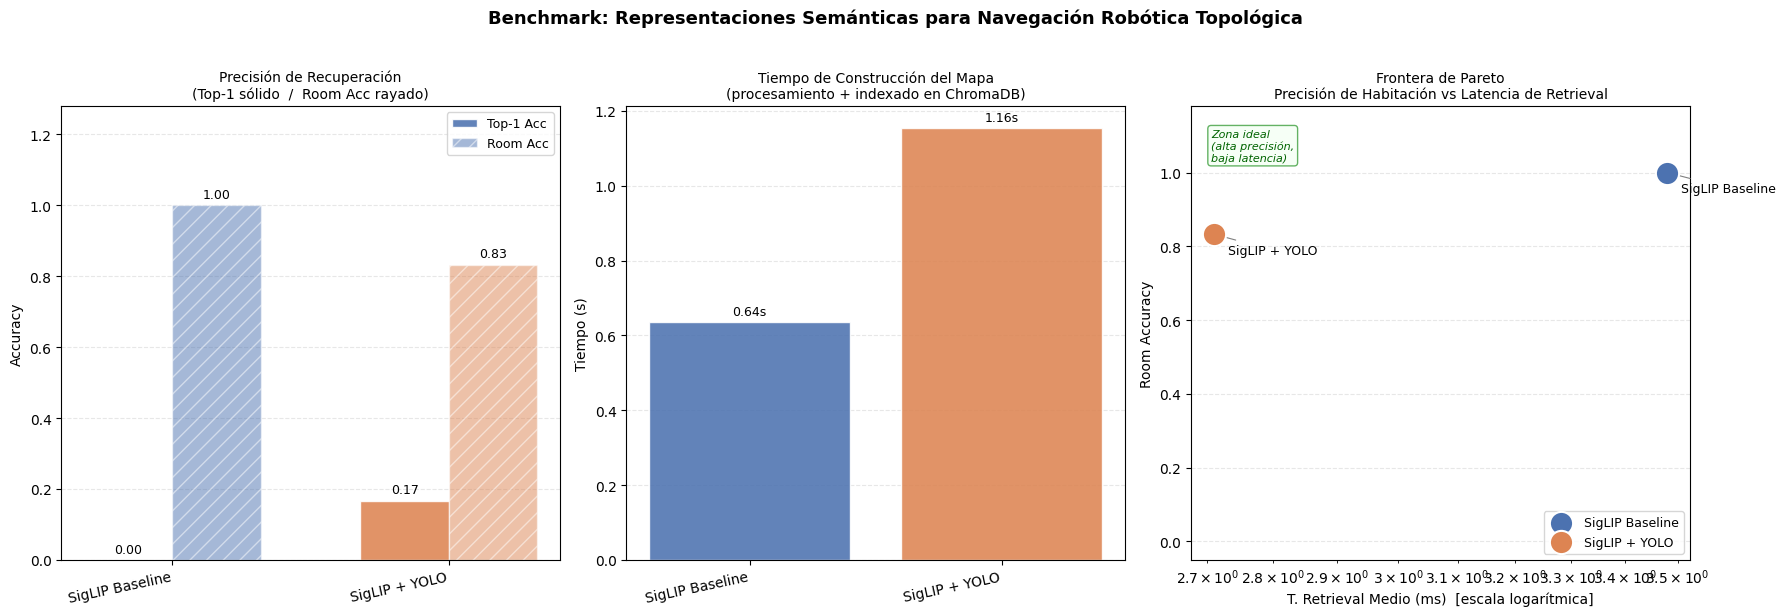

Gráficos guardados en: /home/junior/visual_semantic_navigation/experiments/benchmark_data/benchmark_results.png

Benchmark completado.


In [21]:
# ============================================================
# 5.2  Gráficos comparativos
# ============================================================

# Filtrar filas con datos válidos
df_plot  = df_results.dropna(subset=["Top-1 Acc", "Room Acc", "T. Construcción (s)"])
methods  = df_plot["Método"].tolist()
palette  = ["#4C72B0", "#DD8452", "#55A868"][:len(methods)]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle(
    "Benchmark: Representaciones Semánticas para Navegación Robótica Topológica",
    fontsize=13, fontweight="bold", y=1.02,
)

# ---- Gráfico 1: Precisión (Top-1 Acc y Room Acc) ----
ax1    = axes[0]
_x, _w = np.arange(len(methods)), 0.32
_b1 = ax1.bar(_x - _w/2, df_plot["Top-1 Acc"].values, _w, label="Top-1 Acc",
              color=palette, alpha=0.88, edgecolor="white")
_b2 = ax1.bar(_x + _w/2, df_plot["Room Acc"].values,  _w, label="Room Acc",
              color=palette, alpha=0.50, hatch="//", edgecolor="white")
ax1.set_xticks(_x)
ax1.set_xticklabels(methods, rotation=12, ha="right", fontsize=10)
ax1.set_ylim(0, 1.28)
ax1.set_ylabel("Accuracy")
ax1.set_title("Precisión de Recuperación\n(Top-1 sólido  /  Room Acc rayado)", fontsize=10)
ax1.legend(loc="upper right", fontsize=9)
ax1.bar_label(_b1, fmt="%.2f", padding=3, fontsize=9)
ax1.bar_label(_b2, fmt="%.2f", padding=3, fontsize=9)
ax1.grid(axis="y", alpha=0.3, linestyle="--")
ax1.set_axisbelow(True)

# ---- Gráfico 2: Tiempo de Construcción del Mapa ----
ax2 = axes[1]
_b3 = ax2.bar(methods, df_plot["T. Construcción (s)"].values,
              color=palette, alpha=0.88, edgecolor="white")
ax2.set_xticklabels(methods, rotation=12, ha="right", fontsize=10)
ax2.set_ylabel("Tiempo (s)")
ax2.set_title("Tiempo de Construcción del Mapa\n(procesamiento + indexado en ChromaDB)", fontsize=10)
ax2.bar_label(_b3, labels=[f"{_v:.2f}s" for _v in df_plot["T. Construcción (s)"].values],
              padding=3, fontsize=9)
ax2.grid(axis="y", alpha=0.3, linestyle="--")
ax2.set_axisbelow(True)

# ---- Gráfico 3: Frontera de Pareto (Room Acc vs T. Retrieval, escala log) ----
ax3 = axes[2]
for _method, _color in zip(methods, palette):
    _row  = df_plot[df_plot["Método"] == _method].iloc[0]
    _xv   = _row["T. Retrieval Medio (ms)"]
    _yv   = _row["Room Acc"]
    ax3.scatter(_xv, _yv, color=_color, s=280, zorder=5, label=_method,
                edgecolors="white", linewidths=1.5)
    ax3.annotate(
        _method,
        xy=(_xv, _yv), xytext=(10, -14), textcoords="offset points", fontsize=9,
        arrowprops=dict(arrowstyle="->", color="gray", lw=0.8),
    )

ax3.set_xlabel("T. Retrieval Medio (ms)  [escala logarítmica]", fontsize=10)
ax3.set_ylabel("Room Accuracy", fontsize=10)
ax3.set_title("Frontera de Pareto\nPrecisión de Habitación vs Latencia de Retrieval", fontsize=10)
ax3.set_ylim(-0.05, 1.18)
ax3.set_xscale("log")
ax3.legend(loc="lower right", fontsize=9)
ax3.grid(alpha=0.3, linestyle="--")
ax3.set_axisbelow(True)
ax3.annotate(
    "Zona ideal\n(alta precisión,\nbaja latencia)",
    xy=(0.04, 0.88), xycoords="axes fraction",
    fontsize=8, color="darkgreen", fontstyle="italic",
    bbox=dict(boxstyle="round,pad=0.3", fc="honeydew", ec="green", alpha=0.6),
)

plt.tight_layout()
_results_img = os.path.join(WORK_DIR, "benchmark_results.png")
plt.savefig(_results_img, dpi=150, bbox_inches="tight")
plt.show()
print(f"Gráficos guardados en: {_results_img}")
print("\nBenchmark completado.")
